# Airbnb Open Data (NYC) — Exploration, nettoyage, ETL vers Redis

Ce notebook documente la démarche complète : exploration du dataset brut, problèmes rencontrés,
nettoyage, puis chargement (ETL) dans Redis (RedisJSON + RediSearch), et enfin les requêtes
d'agrégation qui répondent aux questions métier.

Dataset source : [Airbnb Open Data (Kaggle)](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata)

## 1. Chargement et premier coup d'œil

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df_raw = pd.read_csv("../data/Airbnb_Open_Data.csv", low_memory=False)
print("shape:", df_raw.shape)
df_raw.head(3)

shape: (102599, 26)


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN


In [2]:
df_raw.dtypes

id                                  int64
NAME                                  str
host id                             int64
host_identity_verified                str
host name                             str
neighbourhood group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country code                          str
instant_bookable                   object
cancellation_policy                   str
room type                             str
Construction year                 float64
price                                 str
service fee                           str
minimum nights                    float64
number of reviews                 float64
last review                           str
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

## 2. Problèmes rencontrés sur le jeu de données

On inspecte systématiquement : doublons, valeurs manquantes, catégories mal saisies (fautes de
frappe), colonnes numériques stockées en texte, et valeurs aberrantes.

In [3]:
# 2.1 Valeurs manquantes
null_counts = df_raw.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df_raw) * 100).round(2)
pd.DataFrame({"nulls": null_counts, "pct": null_pct})

,nulls,pct
license,102597,100.00
house_rules,52131,50.81
last review,15893,15.49
reviews per month,15879,15.48
country,532,0.52
availability 365,448,0.44
minimum nights,409,0.40
host name,406,0.40
review rate number,326,0.32
calculated host listings count,319,0.31


**Observation** : `license` est vide à ~99.998% (inexploitable, à supprimer). `house_rules` est
vide à ~51% (texte libre, on la garde en optionnel). `last review` / `reviews per month` sont
vides à ~15.5% chacun — cohérent, ce sont les annonces qui n'ont jamais reçu d'avis (on ne va pas
les supprimer, mais les gérer explicitement : 0 avis).

In [4]:
# 2.2 Doublons
print("Lignes entièrement dupliquées :", df_raw.duplicated().sum())
print("ids dupliqués :", df_raw["id"].duplicated().sum())
df_raw[df_raw.duplicated(keep=False)].sort_values("id").head(4)

Lignes entièrement dupliquées : 541
ids dupliqués : 541


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
9098,6026161,Upper East Side 2 bedroom- close to Hospitals-,65193709566,verified,Juliana,Manhattan,Upper East Side,40.76222,-73.96030,United States,US,False,moderate,Entire home/apt,2008.0,$105,$21,30.0,2.0,6/8/2019,0.21,3.0,34.0,157.0,NaN,NaN
102474,6026161,Upper East Side 2 bedroom- close to Hospitals-,65193709566,verified,Juliana,Manhattan,Upper East Side,40.76222,-73.96030,United States,US,False,moderate,Entire home/apt,2008.0,$105,$21,30.0,2.0,6/8/2019,0.21,3.0,34.0,157.0,NaN,NaN
102475,6026714,Close to East Side Hospitals- Modern 2 Bedroom...,31072202372,verified,Juliana,Manhattan,Upper East Side,40.76249,-73.96217,United States,US,False,moderate,Entire home/apt,2008.0,$285,$57,30.0,6.0,1/31/2019,0.14,3.0,34.0,67.0,"The quieter the better, but otherwise make you...",NaN
9099,6026714,Close to East Side Hospitals- Modern 2 Bedroom...,31072202372,verified,Juliana,Manhattan,Upper East Side,40.76249,-73.96217,United States,US,False,moderate,Entire home/apt,2008.0,$285,$57,30.0,6.0,1/31/2019,0.14,3.0,34.0,67.0,"The quieter the better, but otherwise make you...",NaN


In [5]:
# 2.3 Catégories mal saisies (fautes de frappe)
df_raw["neighbourhood group"].value_counts(dropna=False)

neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
NaN                 29
brookln              1
manhatan             1
Name: count, dtype: int64

**Observation** : `"brookln"` et `"manhatan"` sont des fautes de frappe pour `"Brooklyn"` et
`"Manhattan"`. Il faudra les corriger avant d'indexer, sinon RediSearch créera des facettes
en double.

In [6]:
# 2.4 Colonnes numériques stockées en texte : price, service fee
print(df_raw["price"].dropna().unique()[:5])
print(df_raw["service fee"].dropna().unique()[:5])
print(df_raw["price"].dtype)

<ArrowStringArray>
['$966 ', '$142 ', '$620 ', '$368 ', '$204 ']
Length: 5, dtype: str
<ArrowStringArray>
['$193 ', '$28 ', '$124 ', '$74 ', '$41 ']
Length: 5, dtype: str
str


In [7]:
# 2.5 Valeurs aberrantes sur les colonnes numériques
df_raw[["minimum nights", "availability 365", "Construction year"]].describe()

,minimum nights,availability 365,Construction year
count,102190.000000,102151.000000,102385.000000
mean,8.135845,141.133254,2012.487464
std,30.553781,135.435024,5.765556
min,-1223.000000,-10.000000,2003.000000
25%,2.000000,3.000000,2007.000000
50%,3.000000,96.000000,2012.000000
75%,5.000000,269.000000,2017.000000
max,5645.000000,3677.000000,2022.000000


**Observation** : `minimum nights` descend jusqu'à **-1223** et monte jusqu'à 5645 (impossible en
pratique). `availability 365` descend jusqu'à **-10** et monte jusqu'à 3677, alors qu'une
disponibilité annuelle est bornée entre 0 et 365 jours. Ce sont des erreurs de saisie/export à
corriger (on choisit de **borner (clip)** plutôt que supprimer, pour ne pas perdre toute la ligne
pour une seule valeur aberrante). Les valeurs manquantes de ces deux colonnes (~0.4%) sont
complétées par la **médiane**, plus robuste aux valeurs extrêmes que la moyenne.

### Résumé des problèmes trouvés et décisions de nettoyage

| Problème | Décision |
|---|---|
| 541 lignes 100% dupliquées | Suppression des doublons |
| `license` vide à 99.998% | Colonne supprimée |
| Noms de colonnes hétérogènes (espaces, majuscules) | Renommage en `snake_case` |
| `neighbourhood group` : "brookln", "manhatan" | Correction orthographique |
| `price`, `service fee` en texte (`"$966 "`) | Parsing en `float` |
| `minimum nights` négatif / extrême / manquant | Clip à `[1, 365]` puis complété par la médiane |
| `availability 365` négatif / > 365 / manquant | Clip à `[0, 365]` puis complété par la médiane |
| `last review` en texte | Parsing en `datetime` |
| `reviews per month`, `last review` manquants | Absence d'avis → `0` / `None` explicite, pas de suppression |
| `country`, `country code` constants (US) | Colonnes supprimées (aucune valeur informative) |
| `lat`/`long`/`price`/`neighbourhood group`/`neighbourhood` manquants (< 0.1% des lignes) | Lignes supprimées (champs indispensables à l'indexation géo/facette, volume négligeable) |

## 3. Nettoyage

La logique de nettoyage est factorisée dans `scripts/cleaning.py` (réutilisée plus tard par le
script de chargement Redis et par la WebApp, pour ne pas la dupliquer).

In [8]:
import sys
sys.path.append("..")
from scripts.cleaning import load_and_clean

df = load_and_clean("../data/Airbnb_Open_Data.csv")
print("shape avant :", df_raw.shape, "-> shape après :", df.shape)
df.head(3)

shape avant : (102599, 26) -> shape après : (101760, 23)


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,620.0,124.0,3.0,0.0,NaT,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and..."


In [9]:
# Vérifications post-nettoyage
assert df.duplicated().sum() == 0
assert df["neighbourhood_group"].isin(
    ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
).all()
assert df["minimum_nights"].between(1, 365).all()
assert df["availability_365"].between(0, 365).all()
assert df["price"].dtype == float

df.dtypes

id                                         int64
name                                         str
host_id                                    int64
host_identity_verified                       str
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
lat                                      float64
long                                     float64
instant_bookable                          object
cancellation_policy                          str
room_type                                    str
construction_year                        float64
price                                    float64
service_fee                              float64
minimum_nights                           float64
number_of_reviews                        float64
last_review                       datetime64[us]
reviews_per_month                        float64
review_rate_number                       float64
calculated_host_list

In [10]:
# Sauvegarde du dataset nettoyé (réutilisé par scripts/load_data.py)
df.to_csv("../data/airbnb_clean.csv", index=False)
print(f"{len(df)} lignes écrites dans data/airbnb_clean.csv")

101760 lignes écrites dans data/airbnb_clean.csv


## 4. Modélisation Redis (RedisJSON + RediSearch)

**Choix de modélisation** : une annonce = un document JSON dénormalisé, stocké sous la clé
`listing:<id>`. Toutes les informations utiles (y compris celles de l'hôte) sont embarquées
directement dans le document — pas de jointure, conformément à l'approche orientée document.

```
listing:1001254
{
  "id": 1001254,
  "name": "Clean & quiet apt home by the park",
  "host": { "id": 80014485718, "name": "Madaline", "identity_verified": "unconfirmed", ... },
  "neighbourhood_group": "Brooklyn",
  "neighbourhood": "Kensington",
  "lat": 40.647, "long": -73.972, "geo": "-73.972,40.647",
  "room_type": "Private room",
  "price": 966.0, "service_fee": 193.0,
  "reviews": { "number_of_reviews": 9, "review_rate_number": 4, "last_review": "2021-10-19", ... },
  "availability_365": 286,
  "ingested_at": "2026-08-19T..."
}
```

**Index RediSearch** (`idx:listings`) sur préfixe `listing:` — équivalent des index secondaires /
dénormalisation interrogeable d'une base document :
- `TAG` sur `neighbourhood_group`, `neighbourhood`, `room_type`, `host_id`, `instant_bookable`,
  `cancellation_policy` → filtres/facettes exacts et rapides
- `NUMERIC SORTABLE` sur `price`, `number_of_reviews`, `review_rate_number`, `availability_365`
  → tris et agrégations
- `GEO` sur `geo` (long,lat) → recherche par proximité géographique
- `TEXT` sur `name` → recherche plein texte

Le schéma est défini dans `scripts/redis_schema.py`, réutilisé par le script de chargement et
la WebApp.

## 5. Chargement (ETL) dans Redis

Import en masse via pipeline (voir `scripts/load_data.py`, exécutable en CLI :
`py scripts/load_data.py`). Ici on l'exécute directement depuis le notebook pour visualiser
le résultat.

In [11]:
sys.path.append("../scripts")
from redis_schema import create_index, get_redis_client, listing_key, row_to_doc

r = get_redis_client()
print("Redis PING :", r.ping())

Redis PING : True


In [12]:
import time

create_index(r, drop_existing=True)

start = time.time()
pipe = r.pipeline(transaction=False)
for i, (_, row) in enumerate(df.iterrows(), start=1):
    doc = row_to_doc(row)
    pipe.json().set(listing_key(doc["id"]), "$", doc)
    if i % 1000 == 0:
        pipe.execute()
pipe.execute()

print(f"{len(df)} documents chargés en {time.time() - start:.1f}s")
print("Clés en base :", r.dbsize())

101760 documents chargés en 67.9s
Clés en base : 101760


## 6. CRUD (manipulation des documents)

Démonstration des 4 opérations de base directement en Python via `redis-py` (module RedisJSON).

In [13]:
# CREATE : insertion d'une nouvelle annonce
new_listing = {
    "id": 999999999,
    "name": "Cosy studio near Central Park (demo)",
    "host": {"id": 1, "name": "Demo Host", "identity_verified": "verified", "calculated_listings_count": 1},
    "neighbourhood_group": "Manhattan",
    "neighbourhood": "Upper West Side",
    "lat": 40.787, "long": -73.975, "geo": "-73.975,40.787",
    "room_type": "Entire home/apt",
    "construction_year": 2020,
    "price": 150.0, "service_fee": 30.0,
    "minimum_nights": 2,
    "instant_bookable": True,
    "cancellation_policy": "flexible",
    "reviews": {"number_of_reviews": 0, "reviews_per_month": 0.0, "review_rate_number": None, "last_review": None},
    "availability_365": 300,
    "house_rules": None,
    "ingested_at": pd.Timestamp.utcnow().isoformat(),
}
r.json().set(listing_key(new_listing["id"]), "$", new_listing)
print("Créé :", r.exists(listing_key(new_listing["id"])) == 1)

Créé : True


C:\Users\romai\AppData\Local\Temp\ipykernel_100972\3977835918.py:18: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "ingested_at": pd.Timestamp.utcnow().isoformat(),


In [14]:
# READ : lecture du document complet, puis lecture d'un champ précis
print(r.json().get(listing_key(999999999)))
print("\nPrix uniquement :", r.json().get(listing_key(999999999), "$.price"))

{'id': 999999999, 'name': 'Cosy studio near Central Park (demo)', 'host': {'id': 1, 'name': 'Demo Host', 'identity_verified': 'verified', 'calculated_listings_count': 1}, 'neighbourhood_group': 'Manhattan', 'neighbourhood': 'Upper West Side', 'lat': 40.787, 'long': -73.975, 'geo': '-73.975,40.787', 'room_type': 'Entire home/apt', 'construction_year': 2020, 'price': 150.0, 'service_fee': 30.0, 'minimum_nights': 2, 'instant_bookable': True, 'cancellation_policy': 'flexible', 'reviews': {'number_of_reviews': 0, 'reviews_per_month': 0.0, 'review_rate_number': None, 'last_review': None}, 'availability_365': 300, 'house_rules': None, 'ingested_at': '2026-08-19T13:09:06.161012+00:00'}

Prix uniquement : [150.0]


In [15]:
# UPDATE : mise à jour partielle d'un champ (JSON.SET sur un sous-chemin)
r.json().set(listing_key(999999999), "$.price", 175.0)
print("Nouveau prix :", r.json().get(listing_key(999999999), "$.price"))

# REPLACE : remplacement complet du document
r.json().set(listing_key(999999999), "$", {**new_listing, "price": 200.0, "name": "Renovated studio (demo)"})
print("Après remplacement :", r.json().get(listing_key(999999999), "$.name"), r.json().get(listing_key(999999999), "$.price"))

Nouveau prix : [175.0]
Après remplacement : ['Renovated studio (demo)'] [200.0]


In [16]:
# DELETE : suppression du document
r.json().delete(listing_key(999999999))
print("Supprimé :", r.exists(listing_key(999999999)) == 0)

Supprimé : True


## 7. Rapport analytique — questions métier

Les requêtes d'agrégation sont écrites en RediSearch (`FT.AGGREGATE`, module `redis.commands.search`)
et factorisées dans `scripts/queries.py`, réutilisées telles quelles par la WebApp Streamlit.

**Q1. Quel est le prix moyen des annonces par borough (quartier principal) de New York ?**

,neighbourhood_group,avg_price,n_listings
0,Queens,630.247892,13163
1,Bronx,627.764793,2687
2,Brooklyn,626.477028,41528
3,Staten Island,623.990486,946
4,Manhattan,622.642324,43436


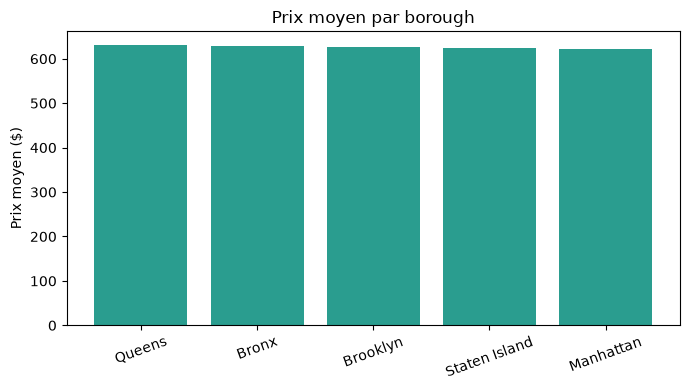

In [17]:
import matplotlib.pyplot as plt
from queries import avg_price_by_neighbourhood_group

q1 = pd.DataFrame(avg_price_by_neighbourhood_group(r))
q1["avg_price"] = q1["avg_price"].astype(float)
q1["n_listings"] = q1["n_listings"].astype(int)
display(q1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(q1["neighbourhood_group"], q1["avg_price"], color="#2a9d8f")
ax.set_ylabel("Prix moyen ($)")
ax.set_title("Prix moyen par borough")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Q2. Le prix moyen dépend-il du type de logement, et cette tendance est-elle la même dans
chaque borough ?**

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group,,,,
Bronx,620.0,NaN,634.4,605.7
Brooklyn,627.0,711.7,625.6,634.2
Manhattan,623.3,681.9,620.6,633.6
Queens,627.0,433.2,631.9,645.2
Staten Island,642.2,NaN,602.2,715.6


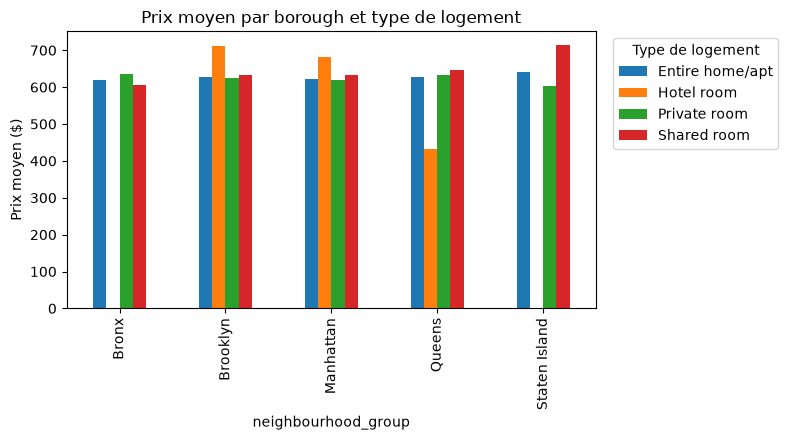

In [18]:
from queries import avg_price_by_room_type_and_group

q2 = pd.DataFrame(avg_price_by_room_type_and_group(r))
q2["avg_price"] = q2["avg_price"].astype(float)
pivot = q2.pivot(index="neighbourhood_group", columns="room_type", values="avg_price")
display(pivot.round(1))

pivot.plot(kind="bar", figsize=(8, 4.5))
plt.ylabel("Prix moyen ($)")
plt.title("Prix moyen par borough et type de logement")
plt.legend(title="Type de logement", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Q3. Quels sont les 10 quartiers (neighbourhood) avec le plus d'annonces, et quel est leur
niveau de prix ?**

,neighbourhood,n_listings,avg_price
0,Bedford-Stuyvesant,7881,623.2
1,Williamsburg,7708,625.3
2,Harlem,5428,626.8
3,Bushwick,4937,633.1
4,Hell's Kitchen,3945,621.1
5,Upper West Side,3832,616.8
6,Upper East Side,3643,619.3
7,East Village,3456,618.1
8,Midtown,3347,609.8
9,Crown Heights,3240,617.3


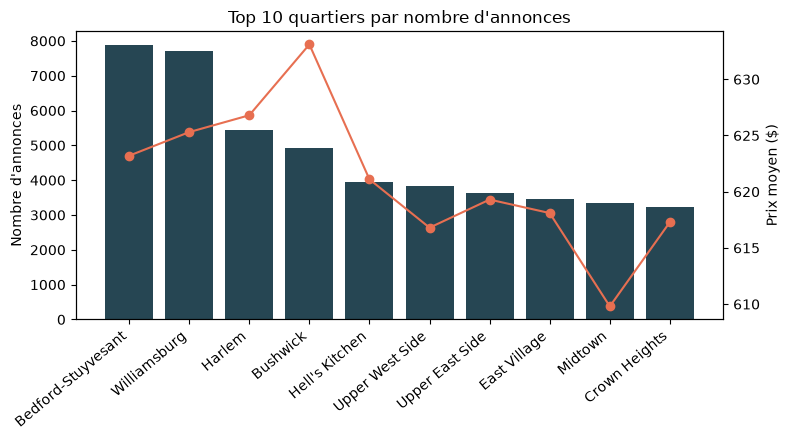

In [19]:
from queries import top_neighbourhoods_by_count

q3 = pd.DataFrame(top_neighbourhoods_by_count(r, n=10))
q3["n_listings"] = q3["n_listings"].astype(int)
q3["avg_price"] = q3["avg_price"].astype(float).round(1)
display(q3)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(q3["neighbourhood"], q3["n_listings"], color="#264653")
ax1.set_ylabel("Nombre d'annonces")
plt.xticks(rotation=40, ha="right")
ax2 = ax1.twinx()
ax2.plot(q3["neighbourhood"], q3["avg_price"], color="#e76f51", marker="o")
ax2.set_ylabel("Prix moyen ($)")
plt.title("Top 10 quartiers par nombre d'annonces")
plt.tight_layout()
plt.show()

**Q4. La disponibilité et le volume d'avis varient-ils selon le type de logement ?**
(logements entiers loués longtemps à l'avance vs chambres privées plus disponibles ?)

In [20]:
from queries import availability_stats_by_room_type

q4 = pd.DataFrame(availability_stats_by_room_type(r))
for col in ["avg_availability", "avg_reviews"]:
    q4[col] = q4[col].astype(float).round(1)
q4["n_listings"] = q4["n_listings"].astype(int)
display(q4)

,room_type,avg_availability,avg_reviews,n_listings
0,Private room,136.4,27.7,46171
1,Hotel room,219.9,84.1,115
2,Entire home/apt,141.6,27.4,53274
3,Shared room,172.1,20.3,2200


**Q5. Qui sont les hôtes ("power hosts") avec le plus d'annonces, et sont-ils mieux notés ?**

⚠️ **Problème rencontré** : grouper par `host_id` ne donne presque aucun "power host" — dans ce
dataset, `host_id` est quasi unique par annonce (101 759 valeurs distinctes pour 101 760 lignes).
La vraie information est dans `calculated_host_listings_count`, un champ **déjà précalculé dans
les données sources** (jusqu'à 332). On l'indexe et on trie directement dessus plutôt que de
grouper sur `host_id`.

In [21]:
from queries import top_hosts_by_listings

q5 = pd.DataFrame(top_hosts_by_listings(r, n=10))
q5

,host_id,host_name,calculated_listings_count,review_rate_number,listing_name
0,83412943157,Blueground,332,2.0,"Bright UES 1BR w/ Doorman, Gym, Roof Deck, nr...."
1,3231719861,Blueground,332,5.0,Stately Midtown East 1BR w/ Doorman near Flati...
2,72619494405,Blueground,332,4.0,"Immaculate Central West Village 1BR, Gym, Door..."
3,18344435096,Blueground,332,5.0,Airy & Bright FiDi Studio w/ Gym + Doorman by ...
4,83842788941,Blueground,332,3.0,Enchanting 1BR near Times Sq w/ Indoor pool + ...
5,90148229302,Blueground,332,2.0,Friendly Midtown East Studio w/ Great light + ...
6,61022727749,Blueground,332,NaN,Dazzling Tribeca 2BR w/ Indoor pool + Great vi...
7,61907398658,Blueground,332,5.0,"Rad Tribeca Studio, Indoor pool + Great views ..."
8,46384126745,Blueground,332,2.0,Fetching FiDi Studio in Luxury Building by Blu...
9,67585934289,Blueground,332,2.0,"Rad Chelsea 1BR w/ Gym, Concierge, nr. Penn St..."


**Q6. Le prix est-il corrélé à la note des annonces (review_rate_number) ou au nombre d'avis ?**
(question "fine" difficile à exprimer en une seule agrégation RediSearch → calculée ici côté
pandas sur le DataFrame nettoyé, en complément des requêtes Redis ci-dessus)

,price,review_rate_number,number_of_reviews,availability_365
price,1.00,-0.00,0.01,-0.00
review_rate_number,-0.00,1.00,-0.02,-0.01
number_of_reviews,0.01,-0.02,1.00,0.10
availability_365,-0.00,-0.01,0.10,1.00


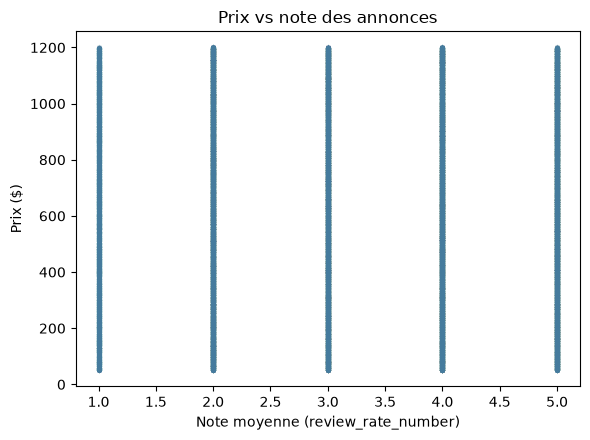

In [22]:
corr = df[["price", "review_rate_number", "number_of_reviews", "availability_365"]].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(df["review_rate_number"], df["price"], alpha=0.05, s=8, color="#457b9d")
ax.set_xlabel("Note moyenne (review_rate_number)")
ax.set_ylabel("Prix ($)")
ax.set_title("Prix vs note des annonces")
plt.tight_layout()
plt.show()

## 8. Suite

- Scripts d'administration (dump/restore, sécurité, perf) : voir `scripts/backup.py`, `scripts/restore.py`.
- WebApp de démonstration interactive : `webapp/app.py` (`streamlit run webapp/app.py`).
- Les fonctions de `scripts/queries.py` utilisées ci-dessus sont directement réutilisées dans la
  WebApp pour éviter toute divergence entre le rapport et la démo.